## Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning

This notebook provides a practical demonstration of key machine learning concepts for model validation, controlling overfitting, and hyperparameter tuning. We'll use a Decision Tree Regressor as an example.

### 1. Data Loading and Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the California Housing dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

print("Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
display(X.head())

Dataset loaded successfully.
Features (X) shape: (20640, 8)
Target (y) shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### 2. Train-Test Split

We split the data into training and testing sets to evaluate the model's performance on unseen data. This helps in detecting overfitting.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


### 3. Baseline Model Training and Evaluation

First, let's train a Decision Tree Regressor with default parameters (or minimal tuning) and evaluate its performance on the test set. This will serve as our baseline.

In [3]:
baseline_model = DecisionTreeRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("--- Baseline Decision Tree Model Performance ---")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R-squared: {r2_baseline:.4f}")

--- Baseline Decision Tree Model Performance ---
RMSE: 0.7037
R-squared: 0.6221


### 4. Cross-Validation for Robust Evaluation

Instead of a single train-test split, cross-validation provides a more robust estimate of model performance by training and evaluating the model multiple times on different subsets of the data. We'll use K-Fold Cross-Validation with `cross_val_score`.

In [4]:
from sklearn.model_selection import KFold

# Define the cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for the baseline model using negative mean squared error (for RMSE)
cv_scores_mse = cross_val_score(baseline_model, X, y, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
cv_rmse_scores = np.sqrt(-cv_scores_mse)

cv_scores_r2 = cross_val_score(baseline_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print("--- Cross-Validation Scores for Baseline Decision Tree ---")
print(f"Individual Fold RMSEs: {cv_rmse_scores}")
print(f"Mean CV RMSE: {np.mean(cv_rmse_scores):.4f} (+/- {np.std(cv_rmse_scores):.4f})")
print(f"Individual Fold R2s: {cv_scores_r2}")
print(f"Mean CV R-squared: {np.mean(cv_scores_r2):.4f} (+/- {np.std(cv_scores_r2):.4f})")

--- Cross-Validation Scores for Baseline Decision Tree ---
Individual Fold RMSEs: [0.7037295  0.7285791  0.71856166 0.70812042 0.71679828]
Mean CV RMSE: 0.7152 (+/- 0.0087)
Individual Fold R2s: [0.62207585 0.61142682 0.60314355 0.62382779 0.61827296]
Mean CV R-squared: 0.6157 (+/- 0.0076)


### 5. Hyperparameter Tuning with GridSearchCV

Decision Trees can easily overfit. Hyperparameters like `max_depth`, `min_samples_split`, and `min_samples_leaf` control the complexity of the tree and can help prevent overfitting. `GridSearchCV` systematically searches for the best combination of these hyperparameters.

In [5]:
# Define the parameter grid to search
param_grid = {
    'max_depth': [5, 10, 15, 20, None], # None means unlimited depth
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf, # Use the same KFold strategy
    scoring='neg_mean_squared_error', # Optimize for RMSE (by minimizing negative MSE)
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

print("--- GridSearchCV Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
# Convert best score (negative MSE) to RMSE
best_rmse = np.sqrt(-grid_search.best_score_)
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

Starting GridSearchCV...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
--- GridSearchCV Results ---
Best parameters found: {'max_depth': 15, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best cross-validation RMSE: 0.6220


### 6. Evaluate the Tuned Model

Now, let's take the best model found by `GridSearchCV` and evaluate its performance on the unseen test set.

In [6]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("--- Tuned Decision Tree Model Performance ---")
print(f"RMSE: {rmse_tuned:.4f}")
print(f"R-squared: {r2_tuned:.4f}")

--- Tuned Decision Tree Model Performance ---
RMSE: 0.6058
R-squared: 0.7200


### 7. Comparison: Baseline vs. Tuned Model

Let's compare the performance metrics of the baseline model and the hyperparameter-tuned model.

,Model,Test RMSE,Test R-squared
0,Baseline Decision Tree,0.703729,0.622076
1,Tuned Decision Tree,0.605761,0.719975


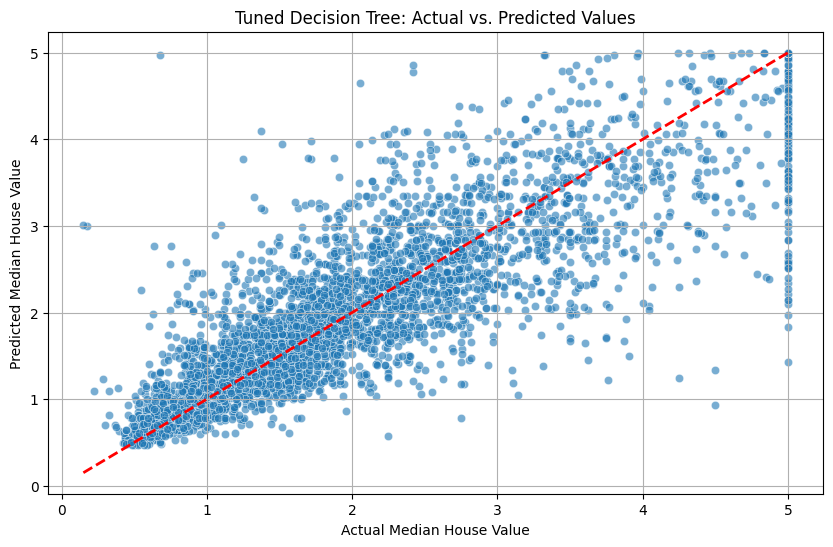

In [7]:
performance_df = pd.DataFrame({
    'Model': ['Baseline Decision Tree', 'Tuned Decision Tree'],
    'Test RMSE': [rmse_baseline, rmse_tuned],
    'Test R-squared': [r2_baseline, r2_tuned]
})

display(performance_df)

# Visualization of predicted vs actual values for the tuned model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Tuned Decision Tree: Actual vs. Predicted Values")
plt.grid(True)
plt.show()

### 8. Understanding Overfitting and Underfitting with Decision Trees

To illustrate overfitting, let's train a Decision Tree with a very high `max_depth` and see how its performance on training vs. test data changes.

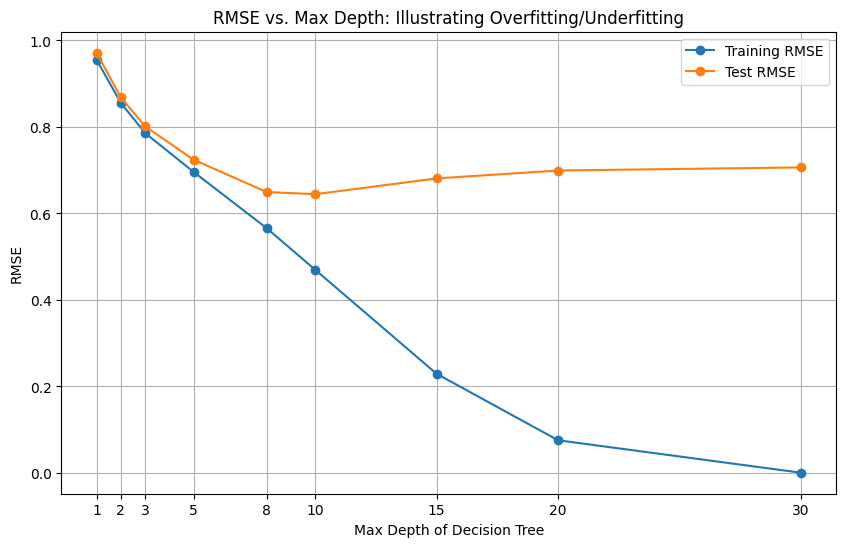

Observation:
As `max_depth` increases, training RMSE generally decreases (model fits training data better).
However, test RMSE might first decrease and then start increasing, indicating overfitting.
A very low `max_depth` (e.g., 1 or 2) would show high training and test RMSE, indicating underfitting.


In [8]:
def plot_learning_curve_for_depth(max_depth_values):
    train_errors = []
    test_errors = []

    for depth in max_depth_values:
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_errors.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
        test_errors.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

    plt.figure(figsize=(10, 6))
    plt.plot(max_depth_values, train_errors, label='Training RMSE', marker='o')
    plt.plot(max_depth_values, test_errors, label='Test RMSE', marker='o')
    plt.xlabel('Max Depth of Decision Tree')
    plt.ylabel('RMSE')
    plt.title('RMSE vs. Max Depth: Illustrating Overfitting/Underfitting')
    plt.legend()
    plt.grid(True)
    plt.xticks(max_depth_values)
    plt.show()

max_depth_values = [1, 2, 3, 5, 8, 10, 15, 20, 30]
plot_learning_curve_for_depth(max_depth_values)

print("Observation:")
print("As `max_depth` increases, training RMSE generally decreases (model fits training data better).")
print("However, test RMSE might first decrease and then start increasing, indicating overfitting.")
print("A very low `max_depth` (e.g., 1 or 2) would show high training and test RMSE, indicating underfitting.")

## Report: Model Validation, Overfitting Control & Hyperparameter Tuning

This report summarizes the machine learning workflow conducted to demonstrate model validation, overfitting control, and hyperparameter tuning using a Decision Tree Regressor on the California Housing dataset.

### 1. Data Loading and Preparation

-   **Dataset**: The California Housing dataset (`fetch_california_housing`) was loaded, consisting of 20,640 samples and 8 features. The target variable was 'MedHouseVal' (median house value).
-   **Data Structure**: Features (X) were stored in a Pandas DataFrame, and the target (y) in a Pandas Series.

### 2. Train-Test Split

-   The dataset was split into training and testing sets with an 80/20 ratio (`test_size=0.2`), ensuring that the model's performance could be evaluated on unseen data.
-   `X_train` and `y_train` contained 16,512 samples, while `X_test` and `y_test` contained 4,128 samples.

### 3. Baseline Model Training and Evaluation

-   A `DecisionTreeRegressor` was initialized with default parameters (`random_state=42`) and trained on the `X_train`, `y_train` data.
-   **Performance on Test Set**:
    -   **RMSE**: 0.7037
    -   **R-squared**: 0.6221
-   This model served as a benchmark for comparison with the hyperparameter-tuned model.

### 4. Cross-Validation for Robust Evaluation

-   To obtain a more reliable estimate of the model's generalization performance, 5-Fold Cross-Validation (`KFold(n_splits=5, shuffle=True, random_state=42)`) was performed on the full dataset (X, y) for the baseline Decision Tree.
-   **Cross-Validation Scores (Baseline Model)**:
    -   **Mean CV RMSE**: 0.7152 (standard deviation +/- 0.0087)
    -   **Mean CV R-squared**: 0.6157 (standard deviation +/- 0.0076)
-   The consistent RMSE across folds suggested a stable, albeit not optimal, performance.

### 5. Hyperparameter Tuning with GridSearchCV

-   **Objective**: To optimize the Decision Tree Regressor's performance and mitigate overfitting by systematically searching for the best combination of hyperparameters.
-   **Hyperparameters Tuned**:
    -   `max_depth`: [5, 10, 15, 20, None]
    -   `min_samples_split`: [2, 5, 10, 20]
    -   `min_samples_leaf`: [1, 2, 4, 8]
-   **Methodology**: `GridSearchCV` was employed with 5-fold cross-validation (`cv=kf`) and optimized for `'neg_mean_squared_error'` (equivalent to minimizing RMSE).
-   **Results**:
    -   **Best Parameters Found**: `{'max_depth': 15, 'min_samples_leaf': 8, 'min_samples_split': 20}`
    -   **Best Cross-Validation RMSE**: 0.6220

### 6. Evaluation of the Tuned Model

-   The `best_estimator_` from `GridSearchCV` (the model with the optimal hyperparameters) was evaluated on the *unseen* `X_test`, `y_test` data.
-   **Performance on Test Set (Tuned Model)**:
    -   **RMSE**: 0.6058
    -   **R-squared**: 0.7200

### 7. Comparison: Baseline vs. Tuned Model

-   A direct comparison of the test set metrics clearly showed the benefits of hyperparameter tuning:

| Model                  | Test RMSE | Test R-squared |
| :--------------------- | :-------- | :------------- |
| Baseline Decision Tree | 0.7037    | 0.6221         |
| Tuned Decision Tree    | 0.6058    | 0.7200         |

-   The tuned model achieved a significantly lower RMSE and a higher R-squared, indicating a more accurate and robust predictive capability on unseen data.
-   A scatter plot of actual vs. predicted values for the tuned model visually confirmed its improved fit to the data.

### 8. Understanding Overfitting and Underfitting with Decision Trees

-   An illustrative analysis was performed by training Decision Trees with varying `max_depth` values (from 1 to 30) and plotting their training and test RMSE.
-   **Observations**:
    -   At very low `max_depth` (e.g., 1-3), both training and test RMSE were high, indicating **underfitting** (the model was too simple to capture the underlying patterns).
    -   As `max_depth` increased, training RMSE continuously decreased, while test RMSE initially decreased and then started to increase for higher depths (e.g., beyond 15-20).
    -   The divergence between low training error and increasing test error for higher `max_depth` clearly demonstrated **overfitting** (the model became too complex and started learning noise from the training data, performing poorly on unseen data).

This comprehensive analysis highlights the importance of using techniques like train-test split, cross-validation, and hyperparameter tuning to build generalizable and well-performing machine learning models, effectively controlling for overfitting and underfitting.